# 01 eda


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [9]:
import os
os.chdir('/home/mosesamwoma/projects/woldcup2026')

df = pd.read_csv('data/raw/results.csv', parse_dates=['date'])

In [5]:
wc_matches = df[df['tournament'] == 'FIFA World Cup']

print(f"World Cup matches: {len(wc_matches):,}")
print(f"World Cups: {wc_matches['date'].dt.year.nunique()}")
wc_matches[['date', 'home_team', 'away_team', 'home_score', 'away_score']].head(10)

World Cup matches: 1,036
World Cups: 23


,date,home_team,away_team,home_score,away_score
1490,1930-07-13,Belgium,United States,0.0,3.0
1491,1930-07-13,France,Mexico,4.0,1.0
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0
1493,1930-07-14,Peru,Romania,1.0,3.0
1494,1930-07-15,Argentina,France,1.0,0.0
1495,1930-07-16,Chile,Mexico,3.0,0.0
1496,1930-07-17,Bolivia,Yugoslavia,0.0,4.0
1497,1930-07-17,Paraguay,United States,0.0,3.0
1499,1930-07-18,Uruguay,Peru,1.0,0.0
1500,1930-07-19,Argentina,Mexico,6.0,3.0


In [10]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


Average goals per match: 2.94
Most common scoreline: 0        0.0-0.0
1        4.0-0.0
2        2.0-0.0
3        2.0-0.0
4        3.0-0.0
          ...   
49432        NaN
49433        NaN
49434        NaN
49435        NaN
49436        NaN
Name: home_score, Length: 49437, dtype: str


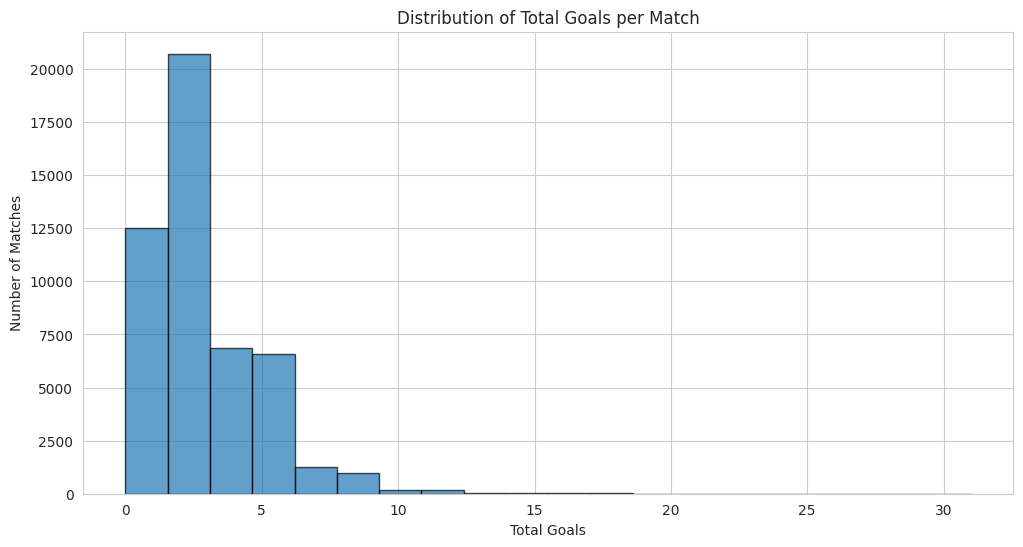

In [11]:
# Calculate total goals per match
df['total_goals'] = df['home_score'] + df['away_score']

print(f"Average goals per match: {df['total_goals'].mean():.2f}")
print(f"Most common scoreline: {df['home_score'].astype(str) + '-' + df['away_score'].astype(str).mode()[0]}")

# Plot goal distribution
plt.hist(df['total_goals'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Total Goals')
plt.ylabel('Number of Matches')
plt.title('Distribution of Total Goals per Match')
plt.show()

Home wins: 48.9%
Away wins: 28.2%
Draws: 22.7%


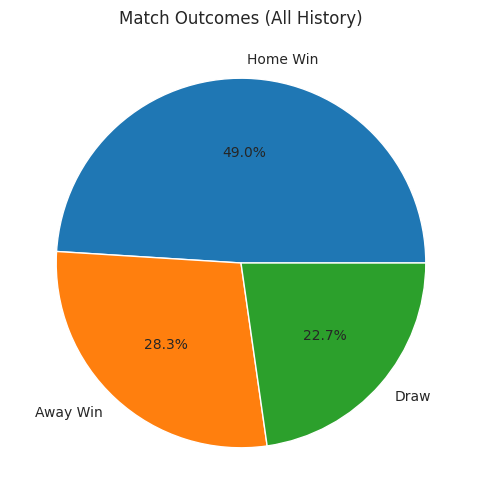

In [12]:
# Calculate home win rate
home_wins = (df['home_score'] > df['away_score']).sum()
away_wins = (df['away_score'] > df['home_score']).sum()
draws = (df['home_score'] == df['away_score']).sum()

print(f"Home wins: {home_wins/len(df)*100:.1f}%")
print(f"Away wins: {away_wins/len(df)*100:.1f}%")
print(f"Draws: {draws/len(df)*100:.1f}%")

# Pie chart
plt.pie([home_wins, away_wins, draws], labels=['Home Win', 'Away Win', 'Draw'], autopct='%1.1f%%')
plt.title('Match Outcomes (All History)')
plt.show()

In [13]:
# Compare World Cup vs non-World Cup
wc_matches = df[df['tournament'] == 'FIFA World Cup']
other_matches = df[df['tournament'] != 'FIFA World Cup']

print(f"World Cup avg goals: {wc_matches['total_goals'].mean():.2f}")
print(f"Other matches avg goals: {other_matches['total_goals'].mean():.2f}")
print(f"World Cup home win %: {(wc_matches['home_score'] > wc_matches['away_score']).sum()/len(wc_matches)*100:.1f}%")
print(f"Other home win %: {(other_matches['home_score'] > other_matches['away_score']).sum()/len(other_matches)*100:.1f}%")

World Cup avg goals: 2.82
Other matches avg goals: 2.94
World Cup home win %: 42.4%
Other home win %: 49.1%


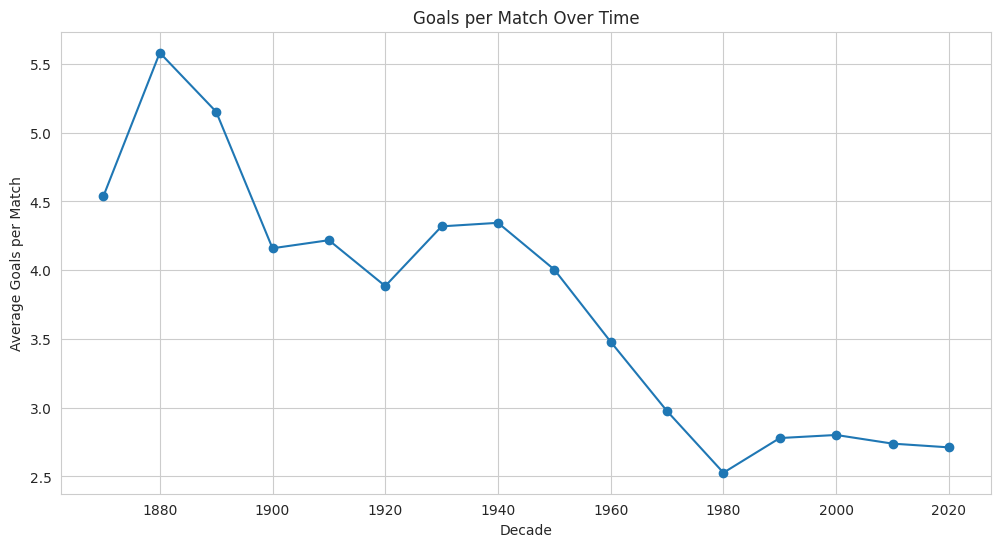

In [14]:
df['decade'] = (df['date'].dt.year // 10) * 10
decade_goals = df.groupby('decade')['total_goals'].mean()

plt.plot(decade_goals.index, decade_goals.values, marker='o')
plt.xlabel('Decade')
plt.ylabel('Average Goals per Match')
plt.title('Goals per Match Over Time')
plt.grid(True)
plt.show()

In [17]:
# Drop rows with missing scores first
df_clean = df.dropna(subset=['home_score', 'away_score'])

# Create scoreline string
df_clean['scoreline'] = df_clean['home_score'].astype(int).astype(str) + '-' + df_clean['away_score'].astype(int).astype(str)

# Get top 10 most common scorelines
top_scorelines = df_clean['scoreline'].value_counts().head(10)

print("Top 10 most common scorelines:")
print(top_scorelines)

Top 10 most common scorelines:
scoreline
1-0    5095
1-1    4904
0-0    3962
2-0    3834
2-1    3768
0-1    3452
1-2    2548
3-0    2358
0-2    2221
2-2    1941
Name: count, dtype: int64


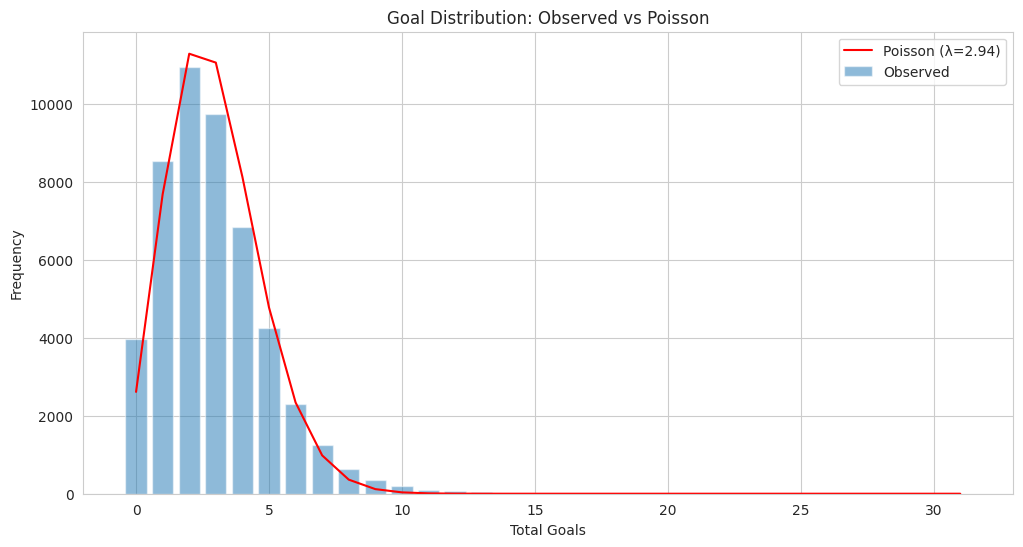

In [16]:
from scipy import stats

# Check if goals follow Poisson distribution
observed = df['total_goals'].value_counts().sort_index()
poisson_mean = df['total_goals'].mean()
expected = stats.poisson.pmf(observed.index, poisson_mean) * len(df)

plt.bar(observed.index, observed.values, alpha=0.5, label='Observed')
plt.plot(observed.index, expected, 'r-', label=f'Poisson (λ={poisson_mean:.2f})')
plt.xlabel('Total Goals')
plt.ylabel('Frequency')
plt.legend()
plt.title('Goal Distribution: Observed vs Poisson')
plt.show()